In [1]:
import pandas as pd

df = pd.read_csv("UPI_Daily_Statistics_2021_2026.csv")

df.head()

,Date,Month,Year,Volume_Million,Value_Crore
0,2021-06-01,June,2021,97.807,21837.51
1,2021-06-02,June,2021,98.137,20668.35
2,2021-06-03,June,2021,92.800,19629.84
3,2021-06-04,June,2021,90.824,18987.07
4,2021-06-05,June,2021,92.120,18465.68


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1856 entries, 0 to 1855
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1856 non-null   object 
 1   Month           1856 non-null   object 
 2   Year            1856 non-null   int64  
 3   Volume_Million  1856 non-null   float64
 4   Value_Crore     1856 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 72.6+ KB


In [3]:
df.shape

(1856, 5)

In [4]:
df.describe()

,Year,Volume_Million,Value_Crore
count,1856.000000,1856.000000,1856.000000
mean,2023.455819,404.857383,57971.642321
std,1.520813,203.023788,25078.855962
min,2021.000000,85.062000,11945.990000
25%,2022.000000,222.260250,36615.825000
50%,2023.000000,387.702500,56805.105000
75%,2025.000000,584.889750,77065.790000
max,2026.000000,801.560000,131735.460000


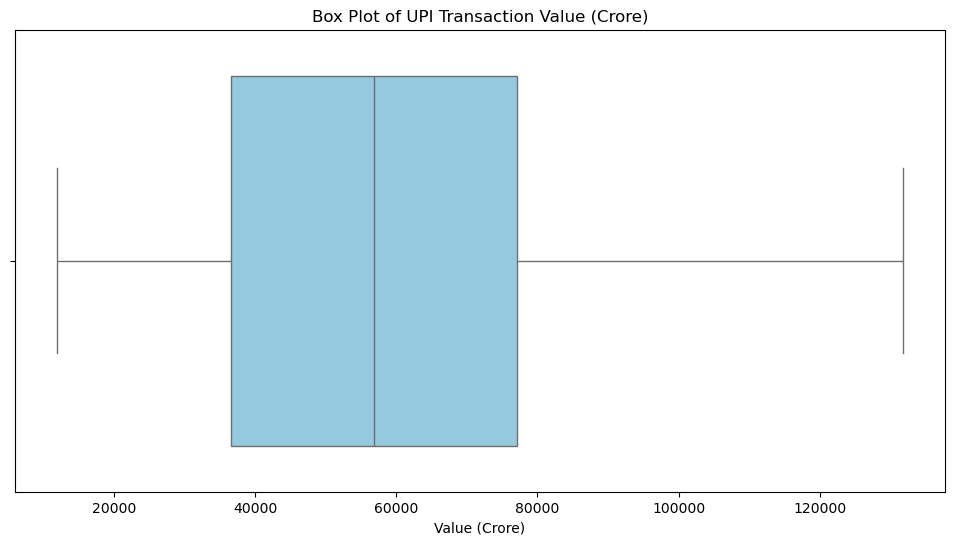

In [5]:
#Python Code (Matplotlib + Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    x=df["Value_Crore"],
    color="skyblue"
)

plt.title("Box Plot of UPI Transaction Value (Crore)")
plt.xlabel("Value (Crore)")

plt.show()

In [6]:
#Calculate Outliers Using the IQR Method
Q1 = df["Value_Crore"].quantile(0.25)
Q3 = df["Value_Crore"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1 : 36615.825
Q3 : 77065.79000000001
IQR: 40449.96500000001
Lower Bound: -24059.12250000002
Upper Bound: 137740.73750000002


In [7]:
#Show Outliers
outliers = df[
    (df["Value_Crore"] < lower_bound) |
    (df["Value_Crore"] > upper_bound)
]

print("Total Outliers:", len(outliers))

outliers.sort_values("Date")

Total Outliers: 0


,Date,Month,Year,Volume_Million,Value_Crore


In [8]:
#Convert Date
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
#Convert Numeric Columns
df["Volume_Million"] = pd.to_numeric(df["Volume_Million"])

df["Value_Crore"] = pd.to_numeric(df["Value_Crore"])

In [10]:
#Create New Date Columns
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Month Name"] = df["Date"].dt.strftime("%B")

df["Quarter"] = df["Date"].dt.quarter

df["Day"] = df["Date"].dt.day

df["Week"] = df["Date"].dt.isocalendar().week

df["Weekday"] = df["Date"].dt.day_name()

df["Day Number"] = df["Date"].dt.dayofweek

In [11]:
df.head()

,Date,Month,Year,Volume_Million,Value_Crore,Month Name,Quarter,Day,Week,Weekday,Day Number
0,2021-06-01,6,2021,97.807,21837.51,June,2,1,22,Tuesday,1
1,2021-06-02,6,2021,98.137,20668.35,June,2,2,22,Wednesday,2
2,2021-06-03,6,2021,92.800,19629.84,June,2,3,22,Thursday,3
3,2021-06-04,6,2021,90.824,18987.07,June,2,4,22,Friday,4
4,2021-06-05,6,2021,92.120,18465.68,June,2,5,22,Saturday,5


In [12]:
#Weekend / Weekday
df["Day Type"] = df["Weekday"].isin(
    ["Saturday","Sunday"]
).map({
    True:"Weekend",
    False:"Weekday"
})

In [13]:
df.head()

,Date,Month,Year,Volume_Million,Value_Crore,Month Name,Quarter,Day,Week,Weekday,Day Number,Day Type
0,2021-06-01,6,2021,97.807,21837.51,June,2,1,22,Tuesday,1,Weekday
1,2021-06-02,6,2021,98.137,20668.35,June,2,2,22,Wednesday,2,Weekday
2,2021-06-03,6,2021,92.800,19629.84,June,2,3,22,Thursday,3,Weekday
3,2021-06-04,6,2021,90.824,18987.07,June,2,4,22,Friday,4,Weekday
4,2021-06-05,6,2021,92.120,18465.68,June,2,5,22,Saturday,5,Weekend


In [14]:
#Financial Year
df["Financial Year"] = df["Date"].apply(
    lambda x: f"{x.year}-{x.year+1}"
    if x.month >= 4
    else f"{x.year-1}-{x.year}"
)

In [15]:
df.head()

,Date,Month,Year,Volume_Million,Value_Crore,Month Name,Quarter,Day,Week,Weekday,Day Number,Day Type,Financial Year
0,2021-06-01,6,2021,97.807,21837.51,June,2,1,22,Tuesday,1,Weekday,2021-2022
1,2021-06-02,6,2021,98.137,20668.35,June,2,2,22,Wednesday,2,Weekday,2021-2022
2,2021-06-03,6,2021,92.800,19629.84,June,2,3,22,Thursday,3,Weekday,2021-2022
3,2021-06-04,6,2021,90.824,18987.07,June,2,4,22,Friday,4,Weekday,2021-2022
4,2021-06-05,6,2021,92.120,18465.68,June,2,5,22,Saturday,5,Weekend,2021-2022


In [21]:
#Daily Growth %
df["Volume Growth %"] = (
    df["Volume_Million"]
      .pct_change()*100
)

df["Value Growth %"] = (
    df["Value_Crore"]
      .pct_change()*100
)

In [22]:
df.head()

,Date,Month,Year,Volume_Million,Value_Crore,Month Name,Quarter,Day,Week,Weekday,Day Number,Day Type,Financial Year,Volume Growth %,Value Growth %
0,2021-06-01,6,2021,97.807,21837.51,June,2,1,22,Tuesday,1,Weekday,2021-2022,NaN,NaN
1,2021-06-02,6,2021,98.137,20668.35,June,2,2,22,Wednesday,2,Weekday,2021-2022,0.337399,-5.353907
2,2021-06-03,6,2021,92.800,19629.84,June,2,3,22,Thursday,3,Weekday,2021-2022,-5.438316,-5.024639
3,2021-06-04,6,2021,90.824,18987.07,June,2,4,22,Friday,4,Weekday,2021-2022,-2.129310,-3.274454
4,2021-06-05,6,2021,92.120,18465.68,June,2,5,22,Saturday,5,Weekend,2021-2022,1.426936,-2.746027


In [23]:
df.drop(columns=["Volume Growth %"], inplace=True)
df.drop(columns=["Value Growth %"], inplace=True)

In [24]:
df.head()

,Date,Month,Year,Volume_Million,Value_Crore,Month Name,Quarter,Day,Week,Weekday,Day Number,Day Type,Financial Year
0,2021-06-01,6,2021,97.807,21837.51,June,2,1,22,Tuesday,1,Weekday,2021-2022
1,2021-06-02,6,2021,98.137,20668.35,June,2,2,22,Wednesday,2,Weekday,2021-2022
2,2021-06-03,6,2021,92.800,19629.84,June,2,3,22,Thursday,3,Weekday,2021-2022
3,2021-06-04,6,2021,90.824,18987.07,June,2,4,22,Friday,4,Weekday,2021-2022
4,2021-06-05,6,2021,92.120,18465.68,June,2,5,22,Saturday,5,Weekend,2021-2022


In [25]:
df.to_csv(
    "UPI_Daily_Statistics_Clean.csv",
    index=False
)